<a href="https://colab.research.google.com/github/vishwesh-V/virtue-of-complexity/blob/main/kmz/kmz_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Alignment test:
  row 100 (1935-04-01): target=0.037326 vs next-row excess_ret=0.037326  ✓
  row 500 (1968-08-01): target=0.034306 vs next-row excess_ret=0.034306  ✓
  row 900 (2001-12-01): target=-0.015827 vs next-row excess_ret=-0.015827  ✓
PASS

usable rows: 1188  (1926-12-01 → 2025-11-01)
after standardization: (1152, 19) 1929-12-01 → 2025-11-01
        dp    dy    ep    de  svar    bm  ntis   tbl   lty   ltr   tms   dfy  \
mean  2.17  2.25  2.81  2.83  0.38  2.26  0.41  1.49  4.71  0.24  1.39  1.40   
std   1.24  1.27  1.47  2.13  0.79  1.29  0.75  1.27  3.77  1.33  1.06  1.18   

       dfr  infl  mktret_lag  
mean  0.03  0.40        0.14  
std   1.08  0.76        0.76  
dp row 600 (1976-12-01):
  full-sample : 2.29883028
  truncated   : 2.29883028
  PASS ✓
G shape: (1152, 15)
S shape: (1152, 6)
feature range: -1.0 to 1.0
forecasts: (1140,)  strat retur

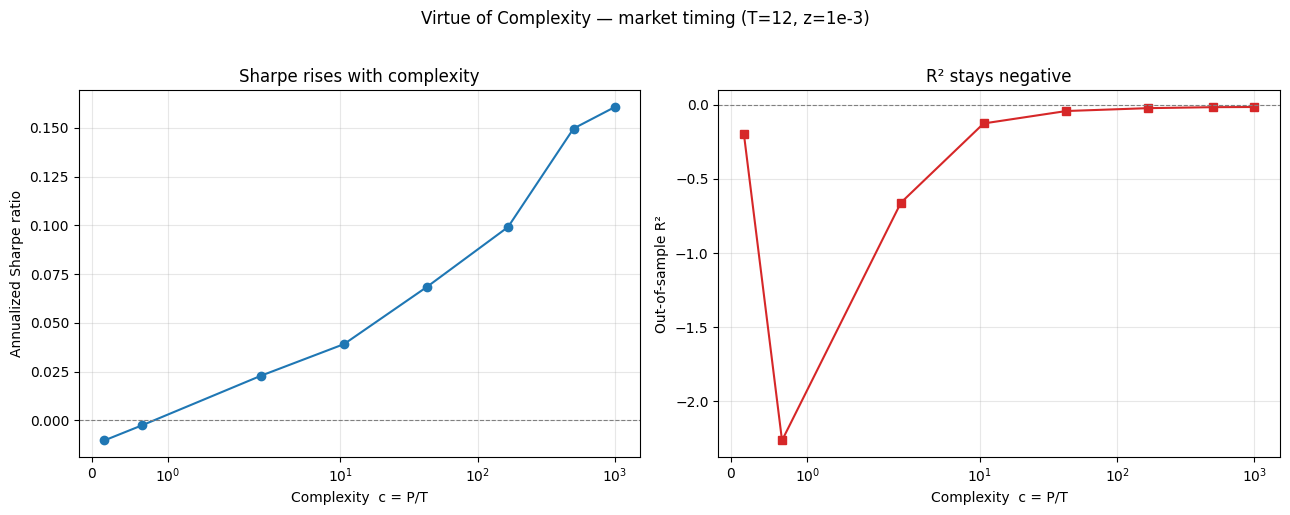

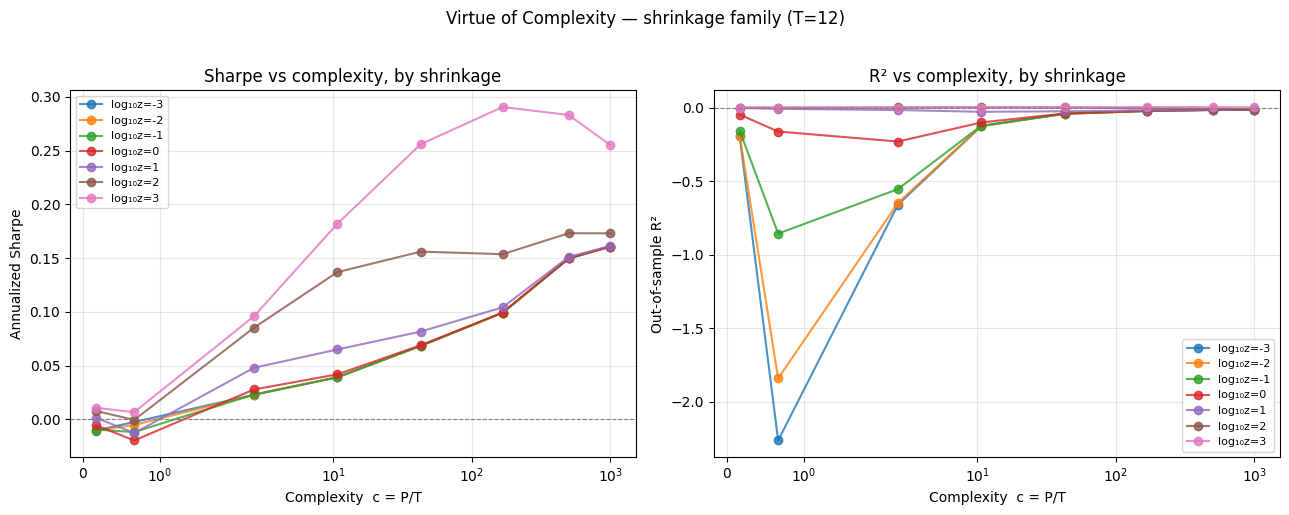

In [9]:
# ============================================================
# kmz_pipeline.ipynb — Stage 0: setup, target alignment, seed policy
# ============================================================
from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ = "/content/drive/MyDrive/Summer Research/kmz"

# --- SEED POLICY ---
MASTER_SEED = 42
def draw_seed(rep: int) -> int:
    """Distinct, reproducible seed for RFF repetition `rep`."""
    return MASTER_SEED * 10_000 + rep

# --- load the cleaned panel (already sorted & cleaned in kmz_data.ipynb) ---
panel = pd.read_parquet(f"{KMZ}/predictors.parquet")

predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]

# --- build the supervised target: predictors at t predict the return at t+1 ---
# (paper p.44 convention: S_t forecasts R_{t+1})
panel["target"] = panel["excess_ret"].shift(-1)

# --- ALIGNMENT UNIT TEST: row t's target must equal row t+1's excess_ret ---
print("Alignment test:")
ok = True
for i in [100, 500, 900]:
    got  = panel.loc[i, "target"]
    want = panel.loc[i+1, "excess_ret"]
    match = abs(got - want) < 1e-12
    ok &= match
    print(f"  row {i} ({panel.loc[i,'date'].date()}): "
          f"target={got:.6f} vs next-row excess_ret={want:.6f}  {'✓' if match else '✗'}")
print("PASS" if ok else "FAIL — target not aligned")

# last row has no t+1 → target is NaN → drop before modeling
panel_model = panel.dropna(subset=["target"]).reset_index(drop=True)
print(f"\nusable rows: {len(panel_model)}  ({panel_model['date'].min().date()} → {panel_model['date'].max().date()})")

# ============================================================
# Stage A — volatility standardization (causal, no look-ahead)
# ============================================================

# Predictors: divide by EXPANDING-window std, using data through t-1 only.
# (No mean subtraction — scale only. Predictors are persistent → use all history.)
def standardize_predictor(s, min_periods=36):
    sd = s.expanding(min_periods=min_periods).std().shift(1)
    return s / sd

# Returns: divide by TRAILING-12-month UNCENTERED std, through t-1 only.
# uncentered 2nd moment = sqrt(mean(x^2)), no mean subtraction.
def standardize_return(r, window=12):
    unc = np.sqrt((r**2).rolling(window).mean()).shift(1)
    return r / unc

# apply to the aligned modeling frame
std = panel_model.copy()
for c in predictors:
    std[c] = standardize_predictor(panel_model[c])
std["target_std"] = standardize_return(panel_model["target"])

# drop warm-up rows (early NaNs from expanding/rolling windows)
std = std.dropna(subset=predictors + ["target_std"]).reset_index(drop=True)
print("after standardization:", std.shape,
      std["date"].min().date(), "→", std["date"].max().date())
print(std[predictors].describe().loc[["mean","std"]].round(2))

# ============================================================
# Stage A gate — LEAKAGE TEST
# recompute a standardized value on data truncated at t;
# it must equal the full-sample value (proves causality).
# ============================================================
test_col, test_i = "dp", 600      # any predictor, any interior row
full_val = standardize_predictor(panel_model[test_col]).iloc[test_i]
trunc_val = standardize_predictor(panel_model[test_col].iloc[:test_i+1]).iloc[test_i]

print(f"{test_col} row {test_i} ({panel_model['date'].iloc[test_i].date()}):")
print(f"  full-sample : {full_val:.8f}")
print(f"  truncated   : {trunc_val:.8f}")
print("  PASS ✓" if abs(full_val - trunc_val) < 1e-12 else "  FAIL ✗ — look-ahead present")

# ============================================================
# Stage B — Random Fourier Features
# 15 standardized predictors → P features via random projections
# ============================================================

def make_rff(G, n_pairs, gamma=2.0, seed=0):
    """
    G       : (T_obs, 15) array of standardized predictors
    n_pairs : number of random omega draws; P = 2*n_pairs features
    gamma   : bandwidth (paper uses 2.0)
    returns : (T_obs, 2*n_pairs) RFF matrix
    """
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((G.shape[1], n_pairs))   # (15, n_pairs) random omegas
    proj = gamma * (G @ W)                            # (T_obs, n_pairs) projections
    return np.concatenate([np.sin(proj), np.cos(proj)], axis=1)  # sin/cos pairs

# --- test it on your standardized predictors ---
G = std[predictors].to_numpy()          # (1152, 15)
S = make_rff(G, n_pairs=3, seed=draw_seed(0))   # tiny test: 3 pairs → 6 features
print("G shape:", G.shape)
print("S shape:", S.shape)              # expect (1152, 6)
print("feature range:", S.min().round(3), "to", S.max().round(3))  # must be within [-1, 1]


# ============================================================
# Stage C — recursive out-of-sample ridge (the core estimator)
# for a fixed (P, T, z): walk through time, fit ridge on trailing
# T months, forecast next month, compute timing-strategy return.
# ============================================================

def ridge_no_intercept(S_tr, R_tr, z):
    """Paper p.18 estimator: beta = (z*I + (1/T) S'S)^-1 (1/T) S'R"""
    T, P = S_tr.shape
    A = z*np.eye(P) + (S_tr.T @ S_tr) / T
    b = (S_tr.T @ R_tr) / T
    return np.linalg.solve(A, b)              # (P,) coefficient vector

def run_oos(G, R, n_pairs, T, z, seed):
    """
    G : (N,15) standardized predictors   R : (N,) target (next-month excess ret)
    n_pairs : P/2 RFF draws   T : training window   z : ridge shrinkage
    returns: forecasts, timing-strategy returns, ||beta||^2 per step
    """
    S_all = make_rff(G, n_pairs, gamma=2.0, seed=seed)   # (N, P) full RFF matrix
    N = len(R)
    forecasts, strat_ret, beta_norms = [], [], []

    for t in range(T, N):                     # need T months of history before first forecast
        S_tr = S_all[t-T:t]                   # trailing T months of features
        R_tr = R[t-T:t]                       # trailing T months of returns

        # 2nd standardization: scale RFFs by their in-training std (paper fn.39)
        sd = S_tr.std(axis=0); sd[sd == 0] = 1.0
        S_tr_z = S_tr / sd
        S_t_z  = S_all[t] / sd                # apply SAME scaling to the OOS month

        beta = ridge_no_intercept(S_tr_z, R_tr, z)
        f_t  = S_t_z @ beta                   # forecast for month t
        forecasts.append(f_t)
        strat_ret.append(f_t * R[t])          # timing return = forecast * realized return
        beta_norms.append(beta @ beta)

    return np.array(forecasts), np.array(strat_ret), np.array(beta_norms)

# ---------- TRACER BULLET: run once at tiny P to prove the machine turns ----------
G = std[predictors].to_numpy()
R = std["target"].to_numpy()                  # raw next-month excess return

f, sr, bn = run_oos(G, R, n_pairs=3, T=12, z=1e-3, seed=draw_seed(0))  # P=6, T=12
print("forecasts:", f.shape, " strat returns:", sr.shape)
ann_sharpe = sr.mean() / sr.std() * np.sqrt(12)
print(f"tracer Sharpe (annualized): {ann_sharpe:.3f}")
print(f"mean ||beta||^2: {bn.mean():.4f}")

# ============================================================
# Stage D — complexity sweep (dual-form ridge, nested draws)
# ------------------------------------------------------------
# Runs the OOS engine across a grid of complexity levels P, many
# random RFF draws each, and averages. Uses two speed tricks:
#   1. NESTED draws  — build the full Pmax feature matrix once per
#      draw; a model of size P just uses its first P columns.
#   2. DUAL-FORM ridge — when P > T, solve a T×T system instead of
#      P×P. Mathematically identical, thousands of times faster.
# ============================================================

def ridge_forecast_dual(S_tr, R_tr, S_t, z):
    """
    Ridge forecast, no intercept, solved in T-space (the 'dual' form).

    Equivalent to the primal estimator from paper p.18:
        beta = (z*I_P + (1/T) S'S)^-1 (1/T) S'R
        forecast = S_t · beta
    but rewritten so the matrix we invert is T×T (e.g. 12×12) rather
    than P×P (e.g. 12000×12000). Identical numbers, far less work
    whenever P > T — which is the whole overparameterized regime.

    Parameters
    ----------
    S_tr : (T, P) training RFF features (already within-window standardized)
    R_tr : (T,)   training targets (next-month excess returns)
    S_t  : (P,)   the out-of-sample month's features
    z    : float  ridge shrinkage

    Returns
    -------
    float : the scalar forecast for the OOS month
    """
    T = S_tr.shape[0]
    K = (S_tr @ S_tr.T) / T                       # (T,T) Gram matrix — tiny
    a = np.linalg.solve(K + z * np.eye(T), R_tr / T)   # solve in T-space
    return float(S_t @ (S_tr.T @ a))              # map dual solution → forecast


def run_oos_nested(S_full, R, P, T, z):
    """
    One out-of-sample pass at complexity P, reusing a pre-built RFF matrix.

    Walks month-by-month: at each t, fit ridge on the trailing T months of
    features (first P columns of S_full), forecast month t, and record the
    timing-strategy return f_t * R_t.

    Parameters
    ----------
    S_full : (N, Pmax) full RFF matrix for this draw; we use columns [:P]
    R      : (N,)  aligned target series (next-month excess returns)
    P      : int   number of features (complexity numerator)
    T      : int   training-window length in months
    z      : float ridge shrinkage

    Returns
    -------
    forecasts : (N-T,) OOS forecasts
    strat_ret : (N-T,) timing-strategy returns (forecast * realized)
    """
    S_all = S_full[:, :P]                         # nested: first P columns
    N = len(R)
    forecasts, strat_ret = [], []

    for t in range(T, N):                         # need T months of history first
        S_tr = S_all[t-T:t]                       # trailing T months (excludes t)
        R_tr = R[t-T:t]

        # 2nd standardization: scale features by their in-training std,
        # apply the SAME scaling to the OOS month (causal — training window only)
        sd = S_tr.std(axis=0); sd[sd == 0] = 1.0
        S_tr_z = S_tr / sd
        S_t_z  = S_all[t] / sd

        f = ridge_forecast_dual(S_tr_z, R_tr, S_t_z, z)   # dual-form forecast
        forecasts.append(f)
        strat_ret.append(f * R[t])                # timing return = bet × outcome

    return np.array(forecasts), np.array(strat_ret)


def run_sweep(G, R, P_grid, z, T, n_draws=20, master_seed=MASTER_SEED):
    """
    Sweep complexity: for each draw, build features once at Pmax; for each P
    in the grid, run the nested OOS pass and record metrics. Average across
    draws (draws cancel the luck of any single random feature set).

    Returns
    -------
    sweep     : DataFrame, one row per P, metrics averaged across draws (for plotting)
    per_draw  : DataFrame, one row per (P, draw) — kept for Phase 3 (Buncic's
                critique attacks the draw-aggregation, so raw draws matter later)
    """
    R_oos = R[T:]                                 # realized returns being forecast
    Pmax  = max(P_grid)
    rows  = []

    for d in range(n_draws):
        # Build the full Pmax-feature matrix ONCE per draw (the expensive step).
        # Seed is unique per draw but reproducible (seed policy).
        S_full = make_rff(G, n_pairs=Pmax // 2, gamma=2.0,
                          seed=master_seed * 100000 + d)

        for P in P_grid:
            f, sr = run_oos_nested(S_full, R, P, T, z)
            r2 = 1 - np.sum((R_oos - f)**2) / np.sum(R_oos**2)   # KMZ OOS R²
            rows.append(dict(
                P=P, complexity=P / T, draw=d, z=z, T=T,
                r2=r2,
                sharpe=sr.mean() / sr.std() * np.sqrt(12),        # annualized
                mean_ret=sr.mean() * 12,
                vol=sr.std() * np.sqrt(12),
            ))
        print(f"  draw {d+1}/{n_draws} done")

    per_draw = pd.DataFrame(rows)

    # Average each metric across draws, one row per P (this is what we plot)
    sweep = (per_draw.groupby("P")
             .agg(complexity=("complexity", "first"),
                  r2=("r2", "mean"),
                  sharpe=("sharpe", "mean"),
                  mean_ret=("mean_ret", "mean"),
                  vol=("vol", "mean"))
             .reset_index())

    print("\n    P      c        R²      Sharpe")
    for _, r in sweep.iterrows():
        print(f"{int(r.P):>6}  {r.complexity:>6.0f}  {r.r2:>7.3f}  {r.sharpe:>7.3f}")

    return sweep, per_draw


# ---------- DEV RUN: full grid now feasible with the dual form ----------
P_grid = [2, 8, 32, 128, 512, 2000, 6000, 12000]
sweep, sweep_raw = run_sweep(G, R, P_grid, z=1e-3, T=12, n_draws=20)

# ============================================================
# Stage D+ — sweep BOTH complexity (P) and shrinkage (z)
# ============================================================
def run_sweep_zgrid(G, R, P_grid, z_grid, T, n_draws=20, master_seed=MASTER_SEED):
    """
    Same nested/dual engine, but now loops over a grid of shrinkage values z
    as well as complexity P. Produces one (R², Sharpe) per (P, z), averaged
    over draws — i.e. the FAMILY of VoC curves the paper plots.
    """
    R_oos = R[T:]
    Pmax  = max(P_grid)
    rows  = []
    for d in range(n_draws):
        S_full = make_rff(G, n_pairs=Pmax // 2, gamma=2.0,
                          seed=master_seed * 100000 + d)     # build once per draw
        for P in P_grid:
            for z in z_grid:                                  # NEW: inner z loop
                f, sr = run_oos_nested(S_full, R, P, T, z)
                r2 = 1 - np.sum((R_oos - f)**2) / np.sum(R_oos**2)
                rows.append(dict(P=P, complexity=P/T, z=z, draw=d,
                                 r2=r2,
                                 sharpe=sr.mean()/sr.std()*np.sqrt(12)))
        print(f"  draw {d+1}/{n_draws} done")
    per_draw = pd.DataFrame(rows)
    sweep = (per_draw.groupby(["P","z"])
             .agg(complexity=("complexity","first"),
                  r2=("r2","mean"), sharpe=("sharpe","mean"))
             .reset_index())
    return sweep, per_draw

# log-spaced shrinkage, matching the paper's log10(z) ∈ {-3..3}
z_grid = [10.0**k for k in range(-3, 4)]        # 1e-3 ... 1e3
P_grid = [2, 8, 32, 128, 512, 2000, 6000, 12000]
sweep_z, sweep_z_raw = run_sweep_zgrid(G, R, P_grid, z_grid, T=12, n_draws=20)

print("\n=== Sharpe by P (rows) × z (cols) ===")
print(sweep_z.pivot(index="P", columns="z", values="sharpe").round(3))
print("\n=== OOS R² by P (rows) × z (cols) ===")
print(sweep_z.pivot(index="P", columns="z", values="r2").round(3))

# ============================================================
# Stage E — the Virtue of Complexity curves
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# --- Sharpe vs complexity (the "virtue") ---
ax[0].plot(sweep["complexity"], sweep["sharpe"], "o-", color="C0")
ax[0].set_xscale("symlog")                       # log x: complexity spans 0→1000
ax[0].axhline(0, color="grey", lw=0.8, ls="--")
ax[0].set_xlabel("Complexity  c = P/T")
ax[0].set_ylabel("Annualized Sharpe ratio")
ax[0].set_title("Sharpe rises with complexity")
ax[0].grid(alpha=0.3)

# --- OOS R² vs complexity (the paradox) ---
ax[1].plot(sweep["complexity"], sweep["r2"], "s-", color="C3")
ax[1].set_xscale("symlog")
ax[1].axhline(0, color="grey", lw=0.8, ls="--")
ax[1].set_xlabel("Complexity  c = P/T")
ax[1].set_ylabel("Out-of-sample R²")
ax[1].set_title("R² stays negative")
ax[1].grid(alpha=0.3)

plt.suptitle("Virtue of Complexity — market timing (T=12, z=1e-3)", y=1.02)
plt.tight_layout(); plt.show()

# ============================================================
# Stage E+ — family of VoC curves, one line per shrinkage z
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for z in z_grid:
    sub = sweep_z[sweep_z["z"] == z].sort_values("complexity")
    lbl = f"log₁₀z={int(np.log10(z))}"
    ax[0].plot(sub["complexity"], sub["sharpe"], "o-", label=lbl, alpha=.8)
    ax[1].plot(sub["complexity"], sub["r2"],     "o-", label=lbl, alpha=.8)

for a in ax:
    a.set_xscale("symlog"); a.axhline(0, color="grey", lw=.8, ls="--")
    a.set_xlabel("Complexity  c = P/T"); a.grid(alpha=.3); a.legend(fontsize=8)
ax[0].set_ylabel("Annualized Sharpe"); ax[0].set_title("Sharpe vs complexity, by shrinkage")
ax[1].set_ylabel("Out-of-sample R²");  ax[1].set_title("R² vs complexity, by shrinkage")
plt.suptitle("Virtue of Complexity — shrinkage family (T=12)", y=1.02)
plt.tight_layout(); plt.show()
fig.savefig(f"{KMZ}/voc_family.png", dpi=150, bbox_inches="tight")
